# Etiquetado de secuencias: Partes del Discurso (POS) y Entidades Nombradas (NER)
### Procesamiento de Lenguaje Natural — Universidad Tecnológica de Bolívar

**Referencia central:** Jurafsky & Martin, *Speech and Language Processing* (3.ª ed., borrador), cap. 17 *Sequence Labeling for Parts of Speech and Named Entities* y Apéndice A *Hidden Markov Models*.

**Datos reales (español):**
| Tarea | Corpus | Esquema | Origen |
|---|---|---|---|
| POS | UD Spanish-AnCora | UPOS (UD define 17; AnCora usa 16, no tiene PART) | Universal Dependencies (GitHub) |
| NER | CoNLL-2002 (español) | BIO: PER, LOC, ORG, MISC | NLTK (`conll2002`) |

**Recorrido (misma tarea, cinco paradigmas):**

`Etiqueta más frecuente → HMM + Viterbi → CRF → Transformer afinado (BETO) → LLM open source local (few-shot)`

### Resultados de aprendizaje
Al terminar, el estudiante podrá:
1. **Analizar** la ambigüedad POS y NER en corpus reales del español y cuantificarla.
2. **Implementar** desde cero un etiquetador HMM con decodificación de Viterbi.
3. **Diseñar** funciones de rasgos para un CRF lineal y **justificar** su efecto con los pesos aprendidos.
4. **Implementar** la alineación de etiquetas BIO con subpalabras para afinar un Transformer.
5. **Evaluar** un LLM local en NER con métricas a nivel de entidad y **criticar** sus modos de falla (entidades no alineables, tipos inválidos, costo).
6. **Comparar** experimentalmente los paradigmas y **argumentar** cuándo conviene cada uno.

> ⚠️ Este notebook no es para "ejecutar y entregar". Cada sección termina con preguntas que se responden **con tus propios resultados**.

## 0. Configuración

Requisitos (ejecutar una vez). Las secciones 6 y 7 requieren `torch` y `transformers`; con GPU son mucho más rápidas, pero hay un **modo rápido** para CPU.

In [1]:
# Paquetes de las secciones 1-5 (ejecutar una vez; luego reiniciar el kernel si se instaló algo)
%pip install -q nltk python-crfsuite pandas matplotlib
# Opcional: verificación con seqeval
# %pip install -q seqeval
# Secciones 6-7 (Transformer y LLM local):
# %pip install -q torch "transformers>=4.56" datasets accelerate

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, re, json, math, random, time, urllib.request
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

# Interruptores de las secciones pesadas
RUN_TRANSFORMER = True   # Sección 6: afinar BETO para NER
RUN_LLM         = True   # Sección 7: LLM open source local

RESULTS = []   # aquí se acumulan las métricas de todos los métodos
def log_result(tarea, metodo, metrica, valor, nota=""):
    RESULTS.append(dict(tarea=tarea, metodo=metodo, metrica=metrica, valor=round(float(valor), 4), nota=nota))

## 1. Los datos y su representación

### 1.1 POS: UD Spanish-AnCora (formato CoNLL-U)
Cada línea es una **palabra sintáctica** con 10 columnas: `ID FORM LEMMA UPOS XPOS FEATS HEAD DEPREL DEPS MISC`.

Detalle clave del español: las contracciones como **"al"** y **"del"** son *tokens multipalabra*. En CoNLL-U aparecen como un rango (`13-14 al`) seguido de las palabras sintácticas (`a` ADP + `el` DET). La etiqueta POS se asigna a **las palabras sintácticas, no a la forma de superficie**.

In [3]:
UD_BASE = "https://raw.githubusercontent.com/UniversalDependencies/UD_Spanish-AnCora/master/"
UD_FILES = {s: f"es_ancora-ud-{s}.conllu" for s in ("train", "dev", "test")}

for split, fname in UD_FILES.items():
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        print("Descargando", fname, "...")
        urllib.request.urlretrieve(UD_BASE + fname, path)
print("OK:", sorted(os.listdir(DATA_DIR)))

OK: ['.ipynb_checkpoints', 'datasetNER.json', 'dataset_reseñas_espanol.csv', 'dataset_sentimientos_500.csv', 'es_ancora-ud-dev.conllu', 'es_ancora-ud-test.conllu', 'es_ancora-ud-train.conllu', 'matilda', 'ner_datasetreference.csv', 'tass']


In [4]:
def load_ud(path):
    # Lector mínimo de CoNLL-U (sin dependencias externas).
    # Devuelve oraciones [(forma, UPOS), ...] con las palabras sintácticas
    # y cuenta los tokens multipalabra (contracciones y clíticos).
    #   ID entero "13"      -> palabra sintáctica (se usa)
    #   ID rango  "13-14"   -> token multipalabra, p. ej. "al" (se cuenta)
    #   ID decimal "8.1"    -> nodo vacío (se ignora)
    sents, mwt, sent = [], Counter(), []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line:
                if sent: sents.append(sent)
                sent = []
                continue
            if line.startswith("#"):
                continue
            cols = line.split("\t")
            tid, form, upos = cols[0], cols[1], cols[3]
            if "-" in tid:
                mwt[form.lower()] += 1
            elif "." not in tid:
                sent.append((form, upos))
    if sent: sents.append(sent)
    return sents, mwt

pos_train, mwt_train = load_ud(os.path.join(DATA_DIR, UD_FILES["train"]))
pos_dev,   _         = load_ud(os.path.join(DATA_DIR, UD_FILES["dev"]))
pos_test,  _         = load_ud(os.path.join(DATA_DIR, UD_FILES["test"]))

for name, S in [("train", pos_train), ("dev", pos_dev), ("test", pos_test)]:
    print(f"{name:5s}: {len(S):6d} oraciones | {sum(len(s) for s in S):7d} palabras")

print("\nTokens multipalabra más frecuentes (train):", mwt_train.most_common(10))
print("\nEjemplo:", pos_train[0][:12])

train:  14287 oraciones |  453039 palabras
dev  :   1654 oraciones |   53476 palabras
test :   1721 oraciones |   53622 palabras

Tokens multipalabra más frecuentes (train): [('del', 5909), ('al', 2680), ('hacerlo', 39), ('hacerse', 25), ('haberse', 20), ('convertirse', 19), ('darle', 15), ('darse', 15), ('enfrentarse', 14), ('reunirse', 13)]

Ejemplo: [('Las', 'DET'), ('reservas', 'NOUN'), ('de', 'ADP'), ('oro', 'NOUN'), ('y', 'CCONJ'), ('divisas', 'NOUN'), ('de', 'ADP'), ('Rusia', 'PROPN'), ('subieron', 'VERB'), ('800', 'NUM'), ('millones', 'NOUN'), ('de', 'ADP')]


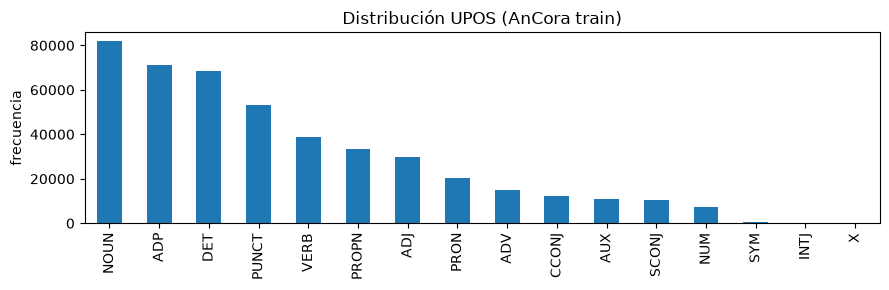

In [5]:
tag_counts = Counter(t for s in pos_train for _, t in s)
ax = pd.Series(tag_counts).sort_values(ascending=False).plot.bar(figsize=(9, 3), title="Distribución UPOS (AnCora train)")
ax.set_ylabel("frecuencia"); plt.tight_layout(); plt.show()

### 1.2 ¿Qué tan ambiguo es el etiquetado POS en español?
Una palabra es **ambigua** si aparece con más de una etiqueta. Medimos dos cosas distintas:
- % de **tipos** (palabras distintas) ambiguos.
- % de **ocurrencias** (tokens) que pertenecen a un tipo ambiguo.

La diferencia entre ambos números es la lección: pocas palabras son ambiguas, pero son las **más frecuentes**.

In [6]:
word_tags = defaultdict(Counter)
for s in pos_train:
    for w, t in s:
        word_tags[w.lower()][t] += 1

amb_types = {w for w, c in word_tags.items() if len(c) > 1}
tok_total = sum(sum(c.values()) for c in word_tags.values())
tok_amb   = sum(sum(word_tags[w].values()) for w in amb_types)
print(f"Tipos ambiguos:  {len(amb_types)/len(word_tags):.1%} de {len(word_tags)} tipos")
print(f"Tokens ambiguos: {tok_amb/tok_total:.1%} de {tok_total} tokens")

top_amb = sorted(amb_types, key=lambda w: -sum(word_tags[w].values()))[:15]
pd.DataFrame([{"palabra": w, "freq": sum(word_tags[w].values()),
               "etiquetas": dict(word_tags[w].most_common(4))} for w in top_amb])

Tipos ambiguos:  10.0% de 34556 tipos
Tokens ambiguos: 51.3% de 453039 tokens


,palabra,freq,etiquetas
0,de,32798,"{'ADP': 32797, 'NOUN': 1}"
1,la,16739,"{'DET': 16474, 'PRON': 265}"
2,que,13207,"{'PRON': 6859, 'SCONJ': 6348}"
3,en,11320,"{'ADP': 11319, 'NOUN': 1}"
4,a,10851,"{'ADP': 10827, 'NOUN': 11, 'PROPN': 6, 'DET': 5}"
5,y,9487,"{'CCONJ': 9485, 'PROPN': 1, 'ADP': 1}"
6,los,7036,"{'DET': 6937, 'PRON': 99}"
7,un,4383,"{'DET': 4347, 'PRON': 24, 'NUM': 12}"
8,las,4350,"{'DET': 4257, 'PRON': 93}"
9,por,4237,"{'ADP': 4236, 'ADV': 1}"


In [7]:
# Palabras ambiguas "didácticas" del español
for w in ["que", "como", "bajo", "sobre", "cara", "vino", "hasta"]:
    if w in word_tags:
        print(f"{w:7s} ->", dict(word_tags[w].most_common()))

que     -> {'PRON': 6859, 'SCONJ': 6348}
como    -> {'SCONJ': 1545, 'ADP': 31, 'PRON': 12, 'CCONJ': 5}
bajo    -> {'ADP': 94, 'ADJ': 18, 'NOUN': 1, 'PROPN': 1}
sobre   -> {'ADP': 726, 'NOUN': 1}
cara    -> {'NOUN': 46, 'ADJ': 3}
vino    -> {'NOUN': 22, 'VERB': 5, 'PROPN': 1}
hasta   -> {'ADP': 460, 'ADV': 38}


### 1.3 NER: CoNLL-2002 (español)
Tres columnas por token: `palabra  POS  etiqueta-BIO`. Tipos: **PER** (persona), **LOC** (lugar), **ORG** (organización), **MISC** (otras: eventos, obras, nacionalidades…).

In [8]:
import nltk
nltk.download("conll2002", quiet=True)
from nltk.corpus import conll2002

def load_conll2002(fileid):
    out = []
    for s in conll2002.iob_sents(fileid):
        if not s: continue
        toks, pos, tags = zip(*s)
        out.append((list(toks), list(pos), list(tags)))
    return out

ner_train = load_conll2002("esp.train")
ner_dev   = load_conll2002("esp.testa")
ner_test  = load_conll2002("esp.testb")
for n, S in [("train", ner_train), ("dev(testa)", ner_dev), ("test(testb)", ner_test)]:
    print(f"{n:12s}: {len(S):5d} oraciones | {sum(len(s[0]) for s in S):6d} tokens")

toks, pos, tags = ner_train[2]
pd.DataFrame({"token": toks, "POS": pos, "BIO": tags}).T

train       :  8323 oraciones | 264715 tokens
dev(testa)  :  1915 oraciones |  52923 tokens
test(testb) :  1517 oraciones |  51533 tokens


,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
token,El,Abogado,General,del,Estado,",",Daryl,Williams,",",subrayó,...,el,cumplimiento,de,los,principios,básicos,de,la,Ley,.
POS,DA,NC,AQ,SP,NC,Fc,VMI,NC,Fc,VMI,...,DA,NC,SP,DA,NC,AQ,SP,DA,NC,Fp
BIO,O,B-PER,I-PER,I-PER,I-PER,O,B-PER,I-PER,O,O,...,O,O,O,O,O,O,O,O,B-MISC,O


### 1.4 Representar *spans* como etiquetas por token: IO, BIO, BIOES
NER es, en realidad, una tarea de **spans** `(inicio, fin, tipo)`. Para convertirla en etiquetado de secuencias codificamos cada span en etiquetas por token:

| Esquema | Etiquetas por tipo | Qué conserva | Qué pierde |
|---|---|---|---|
| **IO** | I | tipo | la frontera entre dos entidades **contiguas del mismo tipo** |
| **BIO** | B, I | tipo + inicio | (nada para spans planos) |
| **BIOES** | B, I, E, S | tipo + inicio + fin + unitario | nada; más etiquetas → más datos requeridos |

Ninguno representa **entidades anidadas** (p. ej. *[Universidad de [Cartagena]LOC]ORG*).

In [9]:
def bio_to_spans(labels):
    # Convierte BIO a spans (inicio, fin_exclusivo, tipo). Un I- sin B- previo abre entidad (convención conlleval).
    spans, start, typ = [], None, None
    for i, lab in enumerate(list(labels) + ["O"]):
        cont = lab.startswith("I-") and typ == lab[2:]
        if not cont:
            if typ is not None:
                spans.append((start, i, typ))
            start, typ = None, None
            if lab[:2] in ("B-", "I-"):
                start, typ = i, lab[2:]
    return spans

def spans_to_bio(spans, n):
    lab = ["O"] * n
    for s, e, t in spans:
        lab[s] = "B-" + t
        for j in range(s + 1, e): lab[j] = "I-" + t
    return lab

def spans_to_io(spans, n):
    lab = ["O"] * n
    for s, e, t in spans:
        for j in range(s, e): lab[j] = "I-" + t
    return lab

def spans_to_bioes(spans, n):
    lab = ["O"] * n
    for s, e, t in spans:
        if e - s == 1: lab[s] = "S-" + t
        else:
            lab[s] = "B-" + t; lab[e - 1] = "E-" + t
            for j in range(s + 1, e - 1): lab[j] = "I-" + t
    return lab

# Buscar en el corpus real un caso de dos entidades contiguas del mismo tipo
for toks, _, tags in ner_train:
    sp = bio_to_spans(tags)
    if any(a[1] == b[0] and a[2] == b[2] for a, b in zip(sp, sp[1:])):
        break
i0 = max(0, min(s for s, _, _ in sp) - 2); i1 = min(len(toks), i0 + 14)
n = len(toks)
demo = pd.DataFrame({"token": toks, "BIO": tags, "IO": spans_to_io(sp, n), "BIOES": spans_to_bioes(sp, n)}).iloc[i0:i1]
print("Spans:", sp)
print("¿IO recupera los spans?", bio_to_spans(spans_to_io(sp, n)) == sp)
demo.T

Spans: [(0, 1, 'ORG'), (2, 3, 'LOC'), (3, 4, 'LOC'), (5, 6, 'LOC'), (11, 12, 'ORG')]
¿IO recupera los spans? False


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
token,EFE,-,Cantabria,Fráncfort,(,RFA,),",",25,may,(,EFECOM,),.
BIO,B-ORG,O,B-LOC,B-LOC,O,B-LOC,O,O,O,O,O,B-ORG,O,O
IO,I-ORG,O,I-LOC,I-LOC,O,I-LOC,O,O,O,O,O,I-ORG,O,O
BIOES,S-ORG,O,S-LOC,S-LOC,O,S-LOC,O,O,O,O,O,S-ORG,O,O


In [10]:
ent_counts = Counter(t for toks, _, tags in ner_train for _, _, t in bio_to_spans(tags))
ent_lens   = Counter(e - s for toks, _, tags in ner_train for s, e, _ in bio_to_spans(tags))
print("Entidades por tipo (train):", dict(ent_counts))
print("Longitud de entidades (tokens):", dict(sorted(ent_lens.items())[:8]))

Entidades por tipo (train): {'LOC': 4914, 'ORG': 7390, 'PER': 4321, 'MISC': 2173}
Longitud de entidades (tokens): {1: 11358, 2: 4039, 3: 1831, 4: 835, 5: 336, 6: 203, 7: 81, 8: 58}


**Preguntas 1.** (a) ¿Por qué el % de tokens ambiguos es mucho mayor que el % de tipos ambiguos? (b) En el ejemplo real anterior, ¿qué información destruye IO? (c) ¿Qué pasa con "al" si un sistema etiqueta la forma de superficie en vez de palabras sintácticas?

## 2. Evaluación: por token (POS) y por entidad (NER)
- **POS** → *accuracy* por token. Reportamos también accuracy en palabras **desconocidas (OOV)**, donde se ve la diferencia real entre modelos.
- **NER** → precisión, recall y F1 **a nivel de entidad**: una entidad cuenta como acierto solo si **inicio, fin y tipo** coinciden exactamente (criterio CoNLL). Acertar 2 de 3 tokens de "Tribunal Supremo de Justicia" vale **cero**.

Implementamos la métrica nosotros para entenderla; si `seqeval` está instalado, lo usamos para verificar.

In [11]:
def pos_accuracy(gold_sents, pred_tags, train_vocab=None):
    ok = tot = ok_oov = tot_oov = 0
    for s, p in zip(gold_sents, pred_tags):
        for (w, g), y in zip(s, p):
            ok += g == y; tot += 1
            if train_vocab is not None and w not in train_vocab:
                ok_oov += g == y; tot_oov += 1
    return ok / tot, (ok_oov / tot_oov if tot_oov else float("nan")), tot_oov / tot

def entity_prf(gold_seqs, pred_seqs):
    stats = defaultdict(lambda: [0, 0, 0])  # tp, fp, fn
    for g, p in zip(gold_seqs, pred_seqs):
        G, P = set(bio_to_spans(g)), set(bio_to_spans(p))
        for s in G & P: stats[s[2]][0] += 1
        for s in P - G: stats[s[2]][1] += 1
        for s in G - P: stats[s[2]][2] += 1
    rows = []
    def prf(tp, fp, fn):
        p = tp / (tp + fp) if tp + fp else 0.0
        r = tp / (tp + fn) if tp + fn else 0.0
        return p, r, (2 * p * r / (p + r) if p + r else 0.0)
    for t in sorted(stats):
        tp, fp, fn = stats[t]; rows.append((t, *prf(tp, fp, fn), tp + fn))
    TP, FP, FN = (sum(v[i] for v in stats.values()) for i in range(3))
    rows.append(("micro", *prf(TP, FP, FN), TP + FN))
    return pd.DataFrame(rows, columns=["tipo", "P", "R", "F1", "soporte"]).set_index("tipo")

try:
    from seqeval.metrics import f1_score as seqeval_f1
    HAS_SEQEVAL = True
except ImportError:
    HAS_SEQEVAL = False
print("seqeval disponible:", HAS_SEQEVAL)

seqeval disponible: False


## 3. Línea base: etiqueta más frecuente
Asignar a cada palabra la etiqueta con la que más veces apareció en entrenamiento. Palabras desconocidas: `PROPN` si empiezan en mayúscula, `NOUN` en otro caso. Es el piso que cualquier modelo debe superar.

In [12]:
train_vocab_pos = {w for s in pos_train for w, _ in s}
wt_exact = defaultdict(Counter)
for s in pos_train:
    for w, t in s: wt_exact[w][t] += 1
mft = {w: c.most_common(1)[0][0] for w, c in wt_exact.items()}

def mft_tag(words):
    return [mft.get(w) or mft.get(w.lower()) or ("PROPN" if w[:1].isupper() else "NOUN") for w in words]

pred = [mft_tag([w for w, _ in s]) for s in pos_test]
acc, acc_oov, oov_rate = pos_accuracy(pos_test, pred, train_vocab_pos)
print(f"POS etiqueta más frecuente: acc={acc:.4f} | acc OOV={acc_oov:.4f} | %OOV={oov_rate:.2%}")
log_result("POS", "Etiqueta más frecuente", "accuracy", acc, f"OOV acc={acc_oov:.3f}")

POS etiqueta más frecuente: acc=0.9344 | acc OOV=0.5272 | %OOV=5.31%


In [13]:
# Mismo baseline para NER: cada token recibe su etiqueta BIO más frecuente
tok_lab = defaultdict(Counter)
for toks, _, tags in ner_train:
    for w, t in zip(toks, tags): tok_lab[w][t] += 1
ner_mft = [[tok_lab[w].most_common(1)[0][0] if w in tok_lab else "O" for w in toks] for toks, _, _ in ner_test]
rep = entity_prf([t for _, _, t in ner_test], ner_mft)
display(rep)
log_result("NER", "Etiqueta más frecuente", "F1 entidad (micro)", rep.loc["micro", "F1"])

,P,R,F1,soporte
tipo,,,,
LOC,0.621385,0.654059,0.637303,1084
MISC,0.236041,0.273529,0.253406,340
ORG,0.555258,0.592143,0.573108,1400
PER,0.367435,0.346939,0.356893,735
micro,0.506717,0.529924,0.518061,3559


**Preguntas 3.** ¿Por qué el baseline es fuerte en POS y débil en NER? Pista: cuenta cuántas entidades del *test* aparecen literalmente en *train*.

## 4. Paradigma estadístico generativo: HMM + Viterbi (desde cero)

Buscamos la secuencia de etiquetas más probable:
$$\hat{t}_{1:n} = \arg\max_{t_{1:n}} \prod_{i=1}^{n} \underbrace{P(w_i \mid t_i)}_{\text{emisión } B} \; \underbrace{P(t_i \mid t_{i-1})}_{\text{transición } A}$$

Dos supuestos: (1) **Markov de orden 1** — la etiqueta depende solo de la anterior; (2) **independencia de salida** — la palabra depende solo de su etiqueta.

**Viterbi** (programación dinámica), en log-espacio:
$$v_i(t) = \max_{t'} \big[v_{i-1}(t') + \log A_{t't}\big] + \log B_t(w_i), \qquad \text{costo } O(n\,T^2)$$

**Palabras desconocidas:** las palabras con frecuencia 1 en *train* se reemplazan por una **firma** (`<UNK-mente>`, `<UNK-CAP>`, `<UNK-NUM>`…). Así el modelo aprende $P(\text{firma}\mid t)$ y puede generalizar. Esto ya es **ingeniería de rasgos**, y es justo lo que el CRF hará de forma más flexible.

In [14]:
class HMMTagger:
    SUFFIXES = ("mente", "ciones", "ción", "dades", "dad", "ando", "iendo", "ados", "adas", "ado", "ada",
                "idos", "idas", "ido", "ida", "ar", "er", "ir", "es", "os", "as", "s")

    def __init__(self, alpha=0.01, min_count=2):
        self.alpha, self.min_count = alpha, min_count

    def signature(self, w):
        if any(ch.isdigit() for ch in w): return "<UNK-NUM>"
        if w[:1].isupper(): return "<UNK-CAP>"
        lw = w.lower()
        for suf in self.SUFFIXES:
            if lw.endswith(suf): return f"<UNK-{suf}>"
        return "<UNK>"

    def norm(self, w):
        return w if w in self.vocab else self.signature(w)

    def fit(self, sents):
        wc = Counter(w for s in sents for w, _ in s)
        self.vocab = {w for w, c in wc.items() if c >= self.min_count}
        self.tags = sorted({t for s in sents for _, t in s}); T = len(self.tags)
        self.tix = {t: i for i, t in enumerate(self.tags)}
        start, trans = np.zeros(T), np.zeros((T, T))
        emis = defaultdict(lambda: np.zeros(T)); tag_tot = np.zeros(T)
        for s in sents:
            prev = None
            for w, t in s:
                j = self.tix[t]
                if prev is None: start[j] += 1
                else: trans[prev, j] += 1
                emis[self.norm(w)][j] += 1; tag_tot[j] += 1
                prev = j
        a = self.alpha; V = len(emis)
        self.log_pi = np.log((start + a) / (start.sum() + a * T))
        self.log_A  = np.log((trans + a) / (trans.sum(1, keepdims=True) + a * T))
        self.log_B  = {w: np.log((c + a) / (tag_tot + a * V)) for w, c in emis.items()}
        self.log_B_unseen = np.log(a / (tag_tot + a * V))
        return self

    def emission(self, w):
        return self.log_B.get(self.norm(w), self.log_B_unseen)

    def viterbi(self, words, return_trellis=False):
        n, T = len(words), len(self.tags)
        V = np.full((n, T), -np.inf); bp = np.zeros((n, T), dtype=int)
        V[0] = self.log_pi + self.emission(words[0])
        for i in range(1, n):
            scores = V[i - 1][:, None] + self.log_A      # (T_prev, T_cur)
            bp[i] = scores.argmax(0)
            V[i] = scores.max(0) + self.emission(words[i])
        path = [int(V[-1].argmax())]
        for i in range(n - 1, 0, -1):
            path.append(int(bp[i, path[-1]]))
        tags = [self.tags[j] for j in reversed(path)]
        return (tags, V, bp) if return_trellis else tags

t0 = time.time()
hmm = HMMTagger(alpha=0.01).fit(pos_train)
print(f"Entrenado en {time.time()-t0:.1f}s | |vocab|={len(hmm.vocab)} | |T|={len(hmm.tags)}")

Entrenado en 2.9s | |vocab|=18842 | |T|=16


In [15]:
t0 = time.time()
pred_hmm = [hmm.viterbi([w for w, _ in s]) for s in pos_test]
acc, acc_oov, _ = pos_accuracy(pos_test, pred_hmm, train_vocab_pos)
print(f"HMM bigrama: acc={acc:.4f} | acc OOV={acc_oov:.4f} | {time.time()-t0:.1f}s")
log_result("POS", "HMM + Viterbi", "accuracy", acc, f"OOV acc={acc_oov:.3f}")

HMM bigrama: acc=0.9636 | acc OOV=0.8166 | 1.7s


### 4.1 Mirar dentro de Viterbi
Tomamos una oración real corta del *test* que contiene una palabra ambigua y mostramos la **trelliza**: para cada posición, el mejor puntaje acumulado $v_i(t)$ de las etiquetas más prometedoras.

In [16]:
AMBIG = {"que", "como", "bajo", "sobre", "hasta", "entre"}
demo_sent = next(s for s in pos_test if 5 <= len(s) <= 10 and any(w.lower() in AMBIG for w, _ in s))
words = [w for w, _ in demo_sent]
tags_pred, V, bp = hmm.viterbi(words, return_trellis=True)

top = sorted(set(tags_pred) | {"NOUN", "VERB", "ADP", "PRON", "SCONJ"})
trellis = pd.DataFrame(V[:, [hmm.tix[t] for t in top]].T, index=top, columns=words).round(1)
print("Oro :", [t for _, t in demo_sent])
print("HMM :", tags_pred)
trellis

Oro : ['ADP', 'PRON', 'PUNCT', 'ADV', 'AUX', 'VERB', 'ADV', 'SCONJ', 'PRON', 'PUNCT']
HMM : ['ADP', 'NOUN', 'PUNCT', 'ADV', 'AUX', 'VERB', 'ADV', 'PRON', 'PRON', 'PUNCT']


,Por,tanto,",",difícilmente,pudieron,existir,antes,que,éstas,.
ADP,-7.6,-29.9,-33.4,-36.7,-47.3,-57.6,-65.3,-72.6,-77.0,-86.9
ADV,-16.8,-16.9,-34.1,-29.8,-47.0,-55.8,-55.1,-72.3,-75.5,-85.7
AUX,-17.9,-26.8,-33.3,-36.3,-38.7,-55.5,-67.3,-71.4,-74.8,-84.7
NOUN,-19.6,-16.7,-32.8,-37.7,-49.2,-58.1,-67.0,-74.5,-77.6,-89.1
PRON,-17.7,-17.3,-33.9,-36.0,-46.9,-57.0,-65.7,-58.8,-68.6,-85.3
PUNCT,-17.8,-28.4,-19.0,-36.4,-47.6,-57.9,-66.4,-72.9,-76.9,-72.7
SCONJ,-17.4,-25.5,-33.9,-35.9,-46.7,-56.5,-64.6,-58.7,-76.3,-87.4
VERB,-18.2,-25.5,-33.2,-36.4,-46.7,-48.2,-66.7,-72.0,-74.7,-84.6


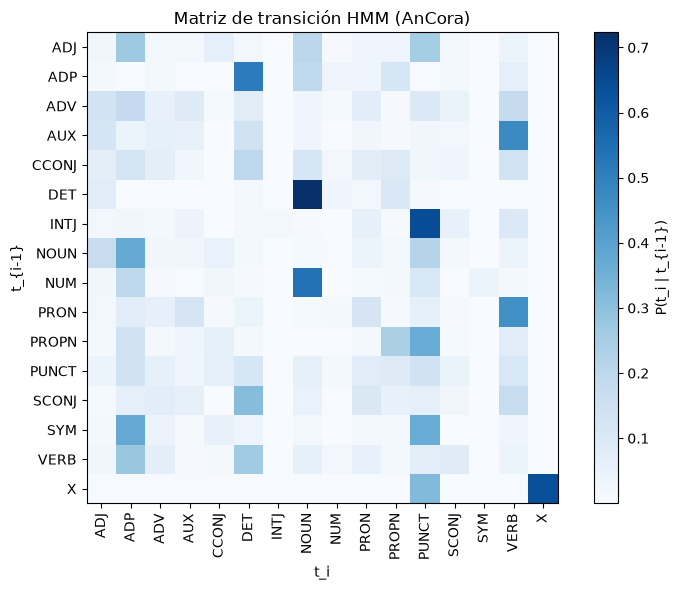

Después de DET, lo más probable: {'NOUN': 0.723, 'PROPN': 0.103, 'ADJ': 0.084}


In [17]:
# Las transiciones aprendidas son interpretables: P(t_i | t_{i-1})
A = pd.DataFrame(np.exp(hmm.log_A), index=hmm.tags, columns=hmm.tags)
plt.figure(figsize=(8, 6)); plt.imshow(A, cmap="Blues"); plt.colorbar(label="P(t_i | t_{i-1})")
plt.xticks(range(len(hmm.tags)), hmm.tags, rotation=90); plt.yticks(range(len(hmm.tags)), hmm.tags)
plt.xlabel("t_i"); plt.ylabel("t_{i-1}"); plt.title("Matriz de transición HMM (AnCora)"); plt.tight_layout(); plt.show()
print("Después de DET, lo más probable:", A.loc["DET"].sort_values(ascending=False).head(3).round(3).to_dict())

**Preguntas 4.** (a) Cambia `alpha` a 1.0 (Laplace). ¿Qué pasa con la accuracy y por qué? (b) Quita las firmas de sufijos (deja solo `<UNK>`): ¿cuánto cae la accuracy OOV? (c) ¿Qué información útil para POS **no puede** usar un HMM por su supuesto de independencia de salida?

## 5. Paradigma discriminativo: CRF de cadena lineal

El CRF modela directamente $P(Y\mid X)$ en vez de $P(X, Y)$:
$$P(Y\mid X) = \frac{1}{Z(X)} \exp\Big(\sum_{i=1}^{n}\sum_k \lambda_k\, f_k(y_{i-1}, y_i, X, i)\Big)$$

La ventaja frente al HMM: las funciones de rasgos $f_k$ pueden mirar **cualquier parte de la entrada** (palabra anterior y siguiente, sufijos, mayúsculas, forma) sin violar ningún supuesto de independencia. La decodificación sigue siendo Viterbi.

Usamos `python-crfsuite` (L-BFGS con regularización L1 + L2).

In [18]:
import pycrfsuite

def shape(w):
    s = re.sub(r"[A-ZÁÉÍÓÚÑÜ]", "X", w)
    s = re.sub(r"[a-záéíóúñü]", "x", s)
    s = re.sub(r"\d", "d", s)
    return re.sub(r"(.)\1+", r"\1\1", s)   # comprime repeticiones: Xxxxx -> Xxx

def word2features(words, i, extra=None):
    w = words[i]; lw = w.lower()
    f = {"bias": 1.0, "w": lw, "suf2": lw[-2:], "suf3": lw[-3:], "suf4": lw[-4:], "pre3": lw[:3],
         "shape": shape(w), "is_title": float(w.istitle()), "is_upper": float(w.isupper()),
         "has_digit": float(any(c.isdigit() for c in w)), "len<=3": float(len(w) <= 3)}
    if extra is not None: f["pos"] = extra[i]
    if i > 0:
        f.update({"-1:w": words[i-1].lower(), "-1:is_title": float(words[i-1].istitle()), "-1:suf3": words[i-1].lower()[-3:]})
        if extra is not None: f["-1:pos"] = extra[i-1]
    else: f["BOS"] = 1.0
    if i < len(words) - 1:
        f.update({"+1:w": words[i+1].lower(), "+1:is_title": float(words[i+1].istitle()), "+1:suf3": words[i+1].lower()[-3:]})
        if extra is not None: f["+1:pos"] = extra[i+1]
    else: f["EOS"] = 1.0
    return f

def sent2features(words, extra=None):
    return [word2features(words, i, extra) for i in range(len(words))]

print(word2features(["El", "Tribunal", "Supremo", "decidió"], 1))

{'bias': 1.0, 'w': 'tribunal', 'suf2': 'al', 'suf3': 'nal', 'suf4': 'unal', 'pre3': 'tri', 'shape': 'Xxx', 'is_title': 1.0, 'is_upper': 0.0, 'has_digit': 0.0, 'len<=3': 0.0, '-1:w': 'el', '-1:is_title': 1.0, '-1:suf3': 'el', '+1:w': 'supremo', '+1:is_title': 1.0, '+1:suf3': 'emo'}


In [ ]:
def train_crf(X, Y, model_path, c1=0.1, c2=0.01, max_iter=100):
    tr = pycrfsuite.Trainer(verbose=False)
    for x, y in zip(X, Y): tr.append(x, y)
    tr.set_params({"c1": c1, "c2": c2, "max_iterations": max_iter, "feature.possible_transitions": True})
    tr.train(model_path)
    tg = pycrfsuite.Tagger(); tg.open(model_path)
    return tg

CRF_POS_MAX_SENTS = None   # None = todo el train; usa p.ej. 4000 para ir más rápido
sub = pos_train if CRF_POS_MAX_SENTS is None else pos_train[:CRF_POS_MAX_SENTS]
t0 = time.time()
crf_pos = train_crf([sent2features([w for w, _ in s]) for s in sub], [[t for _, t in s] for s in sub], "crf_pos.crfsuite")
print(f"CRF POS entrenado con {len(sub)} oraciones en {time.time()-t0:.0f}s")

pred_crf_pos = [crf_pos.tag(sent2features([w for w, _ in s])) for s in pos_test]
acc, acc_oov, _ = pos_accuracy(pos_test, pred_crf_pos, train_vocab_pos)
print(f"CRF POS: acc={acc:.4f} | acc OOV={acc_oov:.4f}")
log_result("POS", "CRF (rasgos manuales)", "accuracy", acc, f"OOV acc={acc_oov:.3f}")

In [ ]:
USE_POS_FEATURES = True   # CoNLL-2002 trae POS: ¿ayuda al NER? Experimenta con False.
def ner_X(data): return [sent2features(toks, pos if USE_POS_FEATURES else None) for toks, pos, _ in data]

t0 = time.time()
crf_ner = train_crf(ner_X(ner_train), [tags for _, _, tags in ner_train], "crf_ner.crfsuite")
pred_crf_ner = [crf_ner.tag(x) for x in ner_X(ner_test)]
rep_crf = entity_prf([t for _, _, t in ner_test], pred_crf_ner)
print(f"CRF NER entrenado en {time.time()-t0:.0f}s")
display(rep_crf)
if HAS_SEQEVAL:
    print("Verificación seqeval F1 micro:", round(seqeval_f1([t for _, _, t in ner_test], pred_crf_ner), 4))
log_result("NER", "CRF (rasgos manuales)", "F1 entidad (micro)", rep_crf.loc["micro", "F1"], f"POS feats={USE_POS_FEATURES}")

### 5.1 El CRF es interpretable: ¿qué aprendió?

In [ ]:
info = crf_ner.info()
state = sorted(info.state_features.items(), key=lambda kv: -kv[1])
print("Rasgos más fuertes a favor de una etiqueta:")
for (feat, lab), wgt in [x for x in state if x[0][1] != "O"][:15]:
    print(f"  {wgt:7.3f}  {lab:7s}  {feat}")
trans = pd.Series({f"{a} → {b}": w for (a, b), w in info.transitions.items()}).sort_values()
print("\nTransiciones más penalizadas:\n", trans.head(6).round(2).to_string())
print("\nTransiciones más favorecidas:\n", trans.tail(6).round(2).to_string())

**Preguntas 5.** (a) ¿Aprendió el CRF por sí mismo que `O → I-PER` es inválido? Muéstralo con los pesos. (b) Elimina un grupo de rasgos (sufijos, forma, contexto) y mide el impacto: ¿cuál importa más para NER y cuál para POS? (c) ¿`USE_POS_FEATURES` mejora el NER? ¿Es realista asumir POS de oro en producción?

## 6. Paradigma neuronal preentrenado: afinar un Transformer (BETO) para NER

Cambio de paradigma: en vez de diseñar rasgos, usamos **representaciones contextuales aprendidas** y añadimos una capa lineal de clasificación por token:
$$P(y_i \mid X) = \text{softmax}(W\, h_i + b), \qquad h_i = \text{Encoder}(X)_i$$

**El problema de la alineación:** el tokenizador parte palabras en **subpalabras** (WordPiece). CoNLL tiene una etiqueta por palabra, el modelo produce una por subpalabra. Estrategia estándar: etiquetar la **primera subpalabra** y asignar `-100` al resto (la función de pérdida las ignora).

Modelo: `dccuchile/bert-base-spanish-wwm-cased` (BETO). Alternativas intercambiables: `PlanTL-GOB-ES/roberta-base-bne`, `xlm-roberta-base`.

> Sin GPU se activa un **modo rápido** (subconjunto de train, 1 época): los números serán menores; la comparación honesta se hace con el entrenamiento completo.

In [ ]:
# Dependencias de las secciones 6 y 7 (solo se instalan si se van a usar)
if RUN_TRANSFORMER or RUN_LLM:
    %pip install -q torch "transformers>=4.56" datasets accelerate

In [ ]:
if RUN_TRANSFORMER:
    import torch
    from datasets import Dataset
    from transformers import (AutoTokenizer, AutoModelForTokenClassification, TrainingArguments,
                              Trainer, DataCollatorForTokenClassification)

    MODEL_NER = "dccuchile/bert-base-spanish-wwm-cased"
    GPU = torch.cuda.is_available()
    FAST_MODE = not GPU
    print("GPU:", GPU, "| FAST_MODE:", FAST_MODE)

    label_list = sorted({t for _, _, tags in ner_train for t in tags})
    label2id = {l: i for i, l in enumerate(label_list)}; id2label = {i: l for l, i in label2id.items()}
    tok = AutoTokenizer.from_pretrained(MODEL_NER)

    # Ver el problema de alineación con una oración real
    toks_demo = ner_train[2][0][:12]; tags_demo = ner_train[2][2][:12]
    enc = tok(toks_demo, is_split_into_words=True)
    rows = []
    for sub_tok, wid in zip(tok.convert_ids_to_tokens(enc["input_ids"]), enc.word_ids()):
        rows.append({"subpalabra": sub_tok, "word_id": "—" if wid is None else wid,
                     "etiqueta": "-100" if wid is None else tags_demo[wid]})
    display(pd.DataFrame(rows).T)

In [ ]:
if RUN_TRANSFORMER:
    def to_ds(data, limit=None):
        data = data if limit is None else data[:limit]
        return Dataset.from_dict({"tokens": [t for t, _, _ in data],
                                  "ner_tags": [[label2id[x] for x in y] for _, _, y in data]})

    def tokenize_and_align(batch):
        enc = tok(batch["tokens"], is_split_into_words=True, truncation=True, max_length=256)
        labels = []
        for b, labs in enumerate(batch["ner_tags"]):
            prev, lab = None, []
            for wid in enc.word_ids(batch_index=b):
                if wid is None:      lab.append(-100)          # [CLS], [SEP]
                elif wid != prev:    lab.append(labs[wid])     # primera subpalabra
                else:                lab.append(-100)          # subpalabras siguientes
                prev = wid
            labels.append(lab)
        enc["labels"] = labels
        return enc

    ds_train = to_ds(ner_train, 2000 if FAST_MODE else None).map(tokenize_and_align, batched=True, remove_columns=["tokens", "ner_tags"])
    ds_dev   = to_ds(ner_dev,   500  if FAST_MODE else None).map(tokenize_and_align, batched=True, remove_columns=["tokens", "ner_tags"])

    def decode_preds(logits, labels):
        pred_ids = logits.argmax(-1)
        G, P = [], []
        for p_row, l_row in zip(pred_ids, labels):
            G.append([id2label[l] for l in l_row if l != -100])
            P.append([id2label[p] for p, l in zip(p_row, l_row) if l != -100])
        return G, P

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        G, P = decode_preds(logits, labels)
        r = entity_prf(G, P).loc["micro"]
        return {"precision": r["P"], "recall": r["R"], "f1": r["F1"]}

    model = AutoModelForTokenClassification.from_pretrained(MODEL_NER, num_labels=len(label_list),
                                                            id2label=id2label, label2id=label2id,
                                                            ignore_mismatched_sizes=True)
    args = TrainingArguments(output_dir="beto-ner-conll2002", learning_rate=3e-5,
                             per_device_train_batch_size=16, per_device_eval_batch_size=32,
                             num_train_epochs=1 if FAST_MODE else 3, weight_decay=0.01,
                             eval_strategy="epoch", save_strategy="no", logging_steps=50,
                             report_to="none", seed=SEED)
    trainer = Trainer(model=model, args=args, train_dataset=ds_train, eval_dataset=ds_dev,
                      processing_class=tok, data_collator=DataCollatorForTokenClassification(tok),
                      compute_metrics=compute_metrics)
    t0 = time.time(); trainer.train(); print(f"Entrenamiento: {time.time()-t0:.0f}s")

In [ ]:
if RUN_TRANSFORMER:
    ds_test = to_ds(ner_test).map(tokenize_and_align, batched=True, remove_columns=["tokens", "ner_tags"])
    out = trainer.predict(ds_test)
    G_tr, P_tr = decode_preds(out.predictions, out.label_ids)
    rep_tr = entity_prf(G_tr, P_tr); display(rep_tr)
    log_result("NER", f"Transformer afinado ({MODEL_NER.split('/')[-1]})", "F1 entidad (micro)",
               rep_tr.loc["micro", "F1"], "FAST_MODE" if FAST_MODE else "completo")
    # Nota: si alguna oración supera 256 subpalabras, se trunca; verifica que len(G_tr[i]) == len(ner_test[i][0]).
    trunc = sum(len(g) != len(t) for g, (t, _, _) in zip(G_tr, ner_test))
    print("Oraciones truncadas:", trunc)

**Preguntas 6.** (a) Cambia la estrategia de alineación a "etiquetar todas las subpalabras" (con `I-` en las siguientes). ¿Cambia el F1? (b) ¿Qué entidades acierta el Transformer que el CRF falla? Da 3 ejemplos reales del *test*. (c) Cambia BETO por `xlm-roberta-base`: ¿qué ganas y qué pierdes con un modelo multilingüe?

## 7. Paradigma LLM: NER y POS con un modelo open source local

Ahora **no entrenamos nada**: especificamos la tarea en lenguaje natural (zero-shot) y con ejemplos reales del *train* (few-shot), y pedimos **salida estructurada en JSON**.

Modelo: `Qwen/Qwen2.5-1.5B-Instruct` (Apache-2.0, multilingüe, corre en CPU o en GPUs modestas). Es intercambiable: prueba modelos más grandes si tu hardware lo permite.

**Lo que hay que observar (y lo que se evalúa):**
1. El LLM devuelve **texto**, no etiquetas por token → hay que **alinear** cada entidad con los tokens. Lo que no se puede alinear se cuenta como **entidad no alineable** (alucinación o cambio de forma).
2. Puede inventar **tipos** fuera del esquema, o devolver JSON inválido.
3. Costo: latencia por oración frente al Transformer afinado.

In [ ]:
if RUN_LLM:
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM
    LLM_ID = "Qwen/Qwen2.5-1.5B-Instruct"
    llm_tok = AutoTokenizer.from_pretrained(LLM_ID)
    llm = AutoModelForCausalLM.from_pretrained(
        LLM_ID, dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto")
    llm.eval()

    def chat(messages, max_new_tokens=256):
        text = llm_tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = llm_tok(text, return_tensors="pt").to(llm.device)
        with torch.no_grad():
            out = llm.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
        return llm_tok.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

### 7.1 Especificación de la tarea (prompt)
Seguimos el esquema del curso: **problema → instrucciones → contexto → restricciones → formato → evaluación**. Las definiciones siguen las guías de CoNLL-2002.

In [ ]:
NER_SYSTEM = (
    "Eres un anotador experto de entidades nombradas en español. "
    "Tipos permitidos (y solo estos): PER = personas; LOC = lugares geográficos; "
    "ORG = organizaciones, instituciones, empresas, equipos, agencias; "
    "MISC = otras entidades con nombre propio (eventos, obras, nacionalidades, productos). "
    "Reglas: copia el texto de cada entidad EXACTAMENTE como aparece en la oración, token por token; "
    "no incluyas artículos que no formen parte del nombre; no inventes entidades. "
    'Responde SOLO con JSON: {"entidades": [{"texto": "...", "tipo": "PER|LOC|ORG|MISC"}]}. '
    'Si no hay entidades responde {"entidades": []}.'
)

def gold_json(toks, tags):
    return json.dumps({"entidades": [{"texto": " ".join(toks[s:e]), "tipo": t} for s, e, t in bio_to_spans(tags)]},
                      ensure_ascii=False)

# Few-shot: ejemplos REALES del train (deterministas: los primeros con >=2 tipos de entidad)
# Se excluyen los encabezados de agencia ("Madrid , 25 may ( EFE )") porque no representan la tarea.
FEW_SHOT = [(t, g) for t, _, g in ner_train
            if 12 <= len(t) <= 30 and "EFE" not in t and len(bio_to_spans(g)) >= 3
            and len({x[2] for x in bio_to_spans(g)}) >= 2][:3]

def ner_messages(toks, k_shots=0):
    msgs = [{"role": "system", "content": NER_SYSTEM}]
    for t, g in FEW_SHOT[:k_shots]:
        msgs += [{"role": "user", "content": "Oración: " + " ".join(t)},
                 {"role": "assistant", "content": gold_json(t, g)}]
    msgs.append({"role": "user", "content": "Oración: " + " ".join(toks)})
    return msgs

for t, g in FEW_SHOT: print(" ".join(t), "\n  ->", gold_json(t, g), "\n")

In [ ]:
VALID = {"PER", "LOC", "ORG", "MISC"}

def parse_entities(txt):
    m = re.search(r"\{.*\}", txt, re.S)
    if not m: return None
    try:
        ents = json.loads(m.group(0)).get("entidades", [])
        return ents if isinstance(ents, list) else None
    except (json.JSONDecodeError, AttributeError):
        return None

def align_entities(toks, ents):
    # Alinea texto devuelto por el LLM con los tokens de la oración -> etiquetas BIO
    labels, st = ["O"] * len(toks), Counter()
    for e in ents or []:
        if not isinstance(e, dict): st["formato_invalido"] += 1; continue
        typ = str(e.get("tipo", "")).upper().strip(); et = str(e.get("texto", "")).split()
        if typ not in VALID: st["tipo_invalido"] += 1; continue
        if not et: st["vacia"] += 1; continue
        for i in range(len(toks) - len(et) + 1):
            if toks[i:i + len(et)] == et and all(l == "O" for l in labels[i:i + len(et)]):
                labels[i] = "B-" + typ
                for j in range(i + 1, i + len(et)): labels[j] = "I-" + typ
                st["alineada"] += 1; break
        else:
            st["no_alineable"] += 1
    return labels, st

def run_llm_ner(data, k_shots, n=100):
    G, P, st, lat, fails = [], [], Counter(), [], 0
    for toks, _, gold in data[:n]:
        t0 = time.time(); raw = chat(ner_messages(toks, k_shots)); lat.append(time.time() - t0)
        ents = parse_entities(raw)
        if ents is None: fails += 1
        pred, s = align_entities(toks, ents); st += s
        G.append(gold); P.append(pred)
    return G, P, st, fails, float(np.mean(lat))

In [ ]:
if RUN_LLM:
    N_LLM = 100   # oraciones del test (sube el número si tu hardware lo permite)
    llm_runs = {}
    for k in (0, 3):
        G, P, st, fails, lat = run_llm_ner(ner_test, k_shots=k, n=N_LLM)
        rep = entity_prf(G, P); llm_runs[k] = (G, P)
        print(f"\n=== {k}-shot === JSON inválido: {fails}/{N_LLM} | latencia media: {lat:.2f}s/oración")
        print("Diagnóstico de alineación:", dict(st))
        display(rep)
        log_result("NER", f"LLM {LLM_ID.split('/')[-1]} {k}-shot", "F1 entidad (micro)", rep.loc["micro", "F1"],
                   f"n={N_LLM}; no alineables={st['no_alineable']}; {lat:.2f}s/oración")

    # Comparación justa: mismas N oraciones para el CRF
    rep_crf_n = entity_prf([t for _, _, t in ner_test[:N_LLM]], pred_crf_ner[:N_LLM])
    print("\nCRF en las mismas", N_LLM, "oraciones: F1 =", round(rep_crf_n.loc["micro", "F1"], 4))
    log_result("NER", "CRF (mismas N del LLM)", "F1 entidad (micro)", rep_crf_n.loc["micro", "F1"], f"n={N_LLM}")

### 7.2 POS con LLM: el problema de la longitud
Para POS la salida debe tener **exactamente una etiqueta por token**. Pedimos una lista JSON y medimos cuántas veces el LLM **no respeta la longitud**; la accuracy se calcula solo sobre las oraciones con longitud correcta (y eso ya es un sesgo a su favor).

In [ ]:
UPOS = sorted(hmm.tags)
POS_SYSTEM = ("Eres un anotador de categorías gramaticales (Universal Dependencies). "
              f"Etiquetas permitidas: {', '.join(UPOS)}. "
              "Recibirás tokens numerados. Devuelve SOLO una lista JSON de etiquetas, una por token, en el mismo orden "
              "y con la misma longitud. Nota: 'a' y 'el' de la contracción 'al' ya vienen separados.")

def run_llm_pos(data, n=30):
    ok = tot = mism = inval = 0
    for s in [x for x in data if len(x) <= 15][:n]:
        words = [w for w, _ in s]
        prompt = "\n".join(f"{i+1}. {w}" for i, w in enumerate(words))
        raw = chat([{"role": "system", "content": POS_SYSTEM}, {"role": "user", "content": prompt}], max_new_tokens=200)
        m = re.search(r"\[.*\]", raw, re.S)
        try: pred = json.loads(m.group(0)) if m else []
        except json.JSONDecodeError: pred = []
        if len(pred) != len(words): mism += 1; continue
        inval += sum(p not in UPOS for p in pred)
        ok += sum(p == g for p, (_, g) in zip(pred, s)); tot += len(words)
    return (ok / tot if tot else float("nan")), mism, inval

if RUN_LLM:
    acc_llm, mism, inval = run_llm_pos(pos_test, n=30)
    print(f"LLM POS zero-shot: acc={acc_llm:.4f} (solo oraciones bien alineadas) | longitud incorrecta: {mism}/30 | etiquetas inválidas: {inval}")
    log_result("POS", f"LLM {LLM_ID.split('/')[-1]} 0-shot", "accuracy", acc_llm, f"n=30 cortas; {mism} desalineadas")

**Preguntas 7.** (a) Muestra 5 entidades **no alineables** reales: ¿son alucinaciones o cambios de forma (tildes, artículos, tokenización)? (b) ¿Qué ganaste con 3-shot y a qué costo en tokens/latencia? (c) Con base en tus números, ¿en qué escenario usarías el LLM y en cuál el Transformer afinado? Argumenta con costo, datos anotados disponibles y F1.

## 8. Comparación y análisis de errores

In [ ]:
res = pd.DataFrame(RESULTS)
display(res.sort_values(["tarea", "valor"]))
for tarea, df in res.groupby("tarea"):
    df.plot.barh(x="metodo", y="valor", legend=False, figsize=(7, 0.45 * len(df) + 1), title=f"{tarea}: {df.metrica.iloc[0]}")
    plt.xlim(0, 1); plt.tight_layout(); plt.show()

In [ ]:
def error_breakdown(gold_seqs, pred_seqs):
    # Clasifica los errores de NER: tipo equivocado, frontera equivocada, omitida, espuria
    c = Counter(); examples = defaultdict(list)
    for g, p in zip(gold_seqs, pred_seqs):
        G, P = set(bio_to_spans(g)), set(bio_to_spans(p))
        for s in G - P:
            same_bound = [q for q in P if q[:2] == s[:2]]
            overlap = [q for q in P if q[0] < s[1] and s[0] < q[1]]
            if same_bound: c["tipo equivocado"] += 1; examples["tipo equivocado"].append((s, same_bound[0]))
            elif overlap:  c["frontera equivocada"] += 1
            else:          c["omitida (FN)"] += 1
        for s in P - G:
            if not any(q[0] < s[1] and s[0] < q[1] for q in G): c["espuria (FP)"] += 1
    return c, examples

c, ex = error_breakdown([t for _, _, t in ner_test], pred_crf_ner)
print("Errores del CRF:", dict(c))
conf = Counter((g[2], p[2]) for g, p in ex["tipo equivocado"])
print("Confusiones de tipo (oro -> predicho):", conf.most_common(6))

### Reflexión final (entregable)
Escribe un análisis de **una página** que responda, **con tus números**:
1. ¿Qué paradigma ganó en POS y en NER, y por qué la brecha es distinta en cada tarea?
2. ¿Qué información usa cada modelo (palabra, contexto, forma, conocimiento del mundo) y cómo se refleja en los errores?
3. Riesgos: ¿qué sesgos podría tener un NER entrenado con noticias de agencia de España de 2000 al aplicarse a prensa colombiana actual? ¿Qué implica para anonimización de datos personales?

### Actividades
- **A1 (datos propios).** Recolecta 30 oraciones de prensa regional colombiana, anótalas con BIO (con acuerdo entre dos compañeros, κ de Cohen) y evalúa los tres mejores modelos. ¿Cuánto cae el F1 fuera de dominio?
- **A2 (ablación).** Tabla de ablación de rasgos del CRF (sección 5) con al menos 4 configuraciones.
- **A3 (prompt como especificación).** Diseña dos variantes del prompt NER, formula una hipótesis sobre cuál funcionará mejor **antes** de ejecutarlas, y contrástala.
- **Defensa oral:** explicar Viterbi sobre la trelliza de la sección 4.1 y la alineación de subpalabras de la sección 6.